<a href="https://colab.research.google.com/github/karpondeeros/tumor-classifier-1/blob/main/tumorclassifer1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Setup and import
!pip install h5py
import urllib.request
import os
import gzip
import shutil
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Setup done")

✓ Setup complete


In [3]:
# Download data
os.makedirs('data', exist_ok=True)

# Download files
print("Downloading...")
urllib.request.urlretrieve(
    'https://zenodo.org/record/2546921/files/camelyonpatch_level_2_split_valid_x.h5.gz?download=1',
    'data/valid_x.h5.gz'
)
urllib.request.urlretrieve(
    'https://zenodo.org/record/2546921/files/camelyonpatch_level_2_split_valid_y.h5.gz?download=1',
    'data/valid_y.h5.gz'
)

print("Download complete")

Downloading... this will take 10-15 minutes
✓ Download complete


In [4]:
# Extract/load data
for filename in ['valid_x.h5.gz', 'valid_y.h5.gz']:
    with gzip.open(f'data/{filename}', 'rb') as f_in:
        with open(f'data/{filename[:-3]}', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

# Load
with h5py.File('data/valid_x.h5', 'r') as f:
    X_data = np.array(f['x'])
with h5py.File('data/valid_y.h5', 'r') as f:
    y_data = np.array(f['y'])

print(f"Loaded: {X_data.shape}")


✓ Loaded: (32768, 96, 96, 3)


In [5]:
# Train/Val split

# Subset for faster training
np.random.seed(42)
indices = np.random.choice(len(X_data), 20000, replace=False)
X_subset = X_data[indices]
y_subset = y_data[indices].squeeze()

# Split into train/val
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

# Normalize
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0

# Free up memory
del X_data, y_data, X_subset, y_subset

print(f"Training: {X_train.shape}, Val: {X_val.shape}")

✓ Train: (16000, 96, 96, 3), Val: (4000, 96, 96, 3)


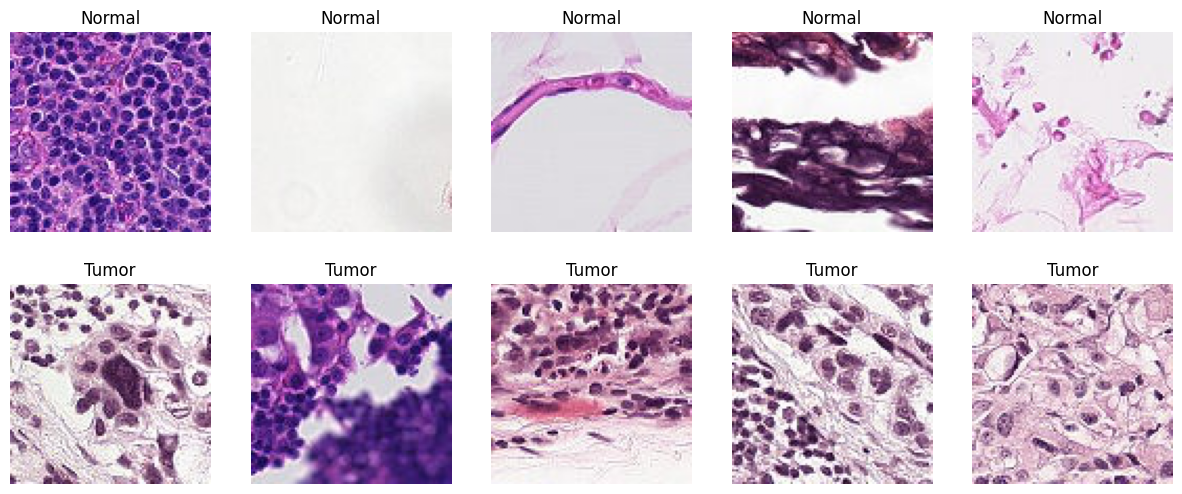

In [6]:
# Data visualization
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

normal_idx = np.where(y_train == 0)[0][:5]
tumor_idx = np.where(y_train == 1)[0][:5]

for i, idx in enumerate(normal_idx):
    axes[0, i].imshow(X_train[idx])
    axes[0, i].set_title('Normal')
    axes[0, i].axis('off')

for i, idx in enumerate(tumor_idx):
    axes[1, i].imshow(X_train[idx])
    axes[1, i].set_title('Tumor')
    axes[1, i].axis('off')

plt.savefig('dataset_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Model building
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
#Model training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("Training done")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7763 - loss: 0.4684

500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 270ms/step - accuracy: 0.8172 - loss: 0.4012 - val_accuracy: 0.8625 - val_loss: 0.3169
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8595 - loss: 0.3266

500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 271ms/step - accuracy: 0.8621 - loss: 0.3174 - val_accuracy: 0.8832 - val_loss: 0.2732
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.8762 - loss: 0.2842

500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 263ms/step - accuracy: 0.8773 - loss: 0.2859 - val_accuracy: 0.8900 - val_loss: 0.2568
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8871 - loss: 0.2627

500/500 ━━━━━━━━━━━━━━━━━━━━ 149s 297ms/step - accuracy: 0.8851 - loss: 0.2650 - val_accuracy: 0.8950 - val_loss: 0.2475
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8898 - loss: 0.2564

...

500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - accuracy: 0.9041 - loss: 0.2243 - val_accuracy: 0.9090 - val_loss: 0.2256
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9087 - loss: 0.2169

500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 258ms/step - accuracy: 0.9099 - loss: 0.2132 - val_accuracy: 0.9097 - val_loss: 0.2267
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 258ms/step - accuracy: 0.9122 - loss: 0.2097 - val_accuracy: 0.9075 - val_loss: 0.2233
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9116 - loss: 0.2048

500/500 ━━━━━━━━━━━━━━━━━━━━ 159s 292ms/step - accuracy: 0.9134 - loss: 0.1985 - val_accuracy: 0.9168 - val_loss: 0.2060
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9230 - loss: 0.1853

500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 261ms/step - accuracy: 0.9201 - loss: 0.1921 - val_accuracy: 0.9195 - val_loss: 0.2142
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9238 - loss: 0.1809

500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - accuracy: 0.9232 - loss: 0.1843 - val_accuracy: 0.9210 - val_loss: 0.2078
Epoch 13/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 265ms/step - accuracy: 0.9272 - loss: 0.1760 - val_accuracy: 0.9153 - val_loss: 0.2157
Epoch 14/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 145s 290ms/step - accuracy: 0.9262 - loss: 0.1704 - val_accuracy: 0.9170 - val_loss: 0.2190
Epoch 15/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - accuracy: 0.9249 - loss: 0.1765 - val_accuracy: 0.9210 - val_loss: 0.2123
✓ Training complete


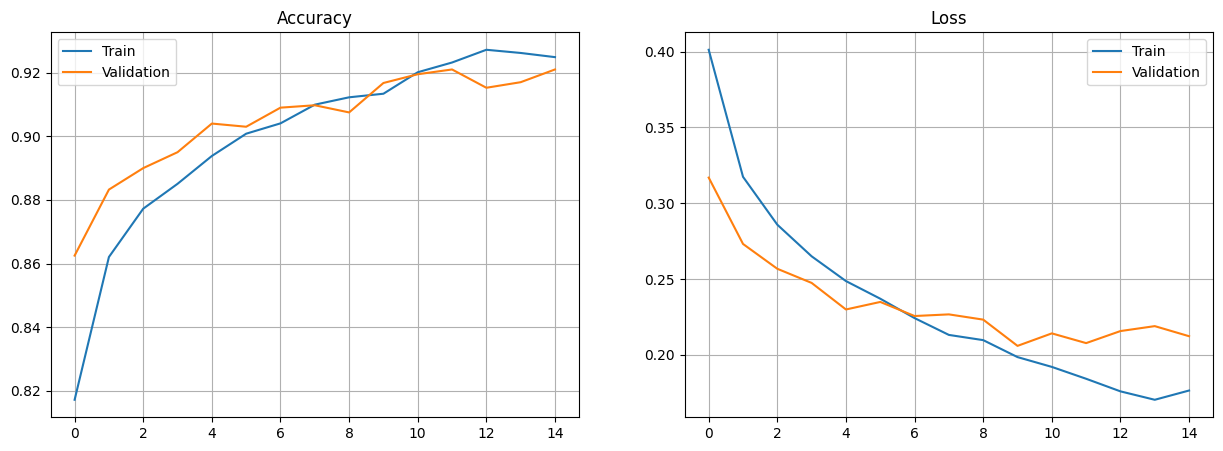

In [9]:
#Plot training

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True)

plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step
Accuracy: 0.9167
AUC-ROC: 0.9759

              precision    recall  f1-score   support

      Normal       0.94      0.89      0.91      1984
       Tumor       0.90      0.94      0.92      2016

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000



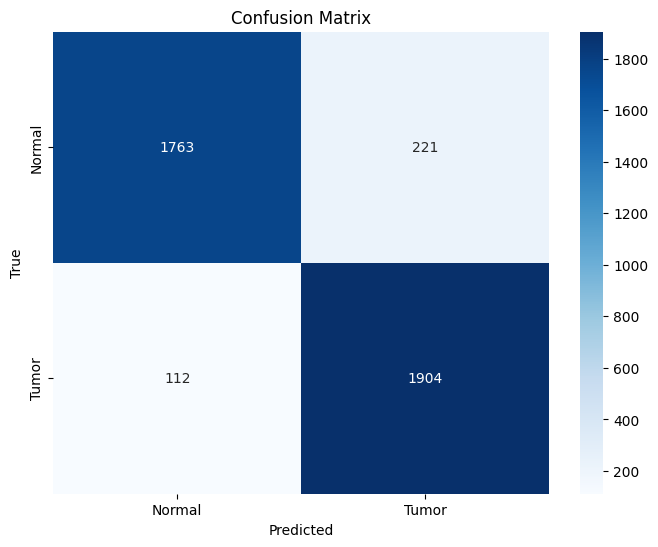

In [10]:
#Evaluation of the model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions
y_pred_proba = model.predict(X_val)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score

accuracy = accuracy_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print("\n" + classification_report(y_val, y_pred, target_names=['Normal', 'Tumor']))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()